## **Conclusion**

Ordinal encoding for education and job level produced worse performance than one-hot encoding.

Therefore, one-hot encoding was retained in the final model.

# **Experiment: Ordinal Encoding
**
## **Objective**

Đánh giá liệu việc sử dụng Ordinal Encoding cho các biến có tính thứ tự:

- job_level
- education

có cải thiện hiệu năng dự đoán lương hay không.

## **Experiment Design**

So sánh hai phiên bản Feature Set A:

1. One-Hot Encoding (Baseline)
2. Ordinal Encoding

Mô hình sử dụng:

- Ridge Regression
- Stratified 5-Fold Cross Validation
- MAE
- RMSE

## **Hypothesis**

Vì `job_level` và `education` có bản chất thứ tự, việc biểu diễn bằng giá trị số có thể giúp mô hình học được quan hệ tăng giảm mức lương tốt hơn so với **One-Hot Encoding**.

## **SECTION 1 - Load Data**

### Load Data

Tải dữ liệu đã được tiền xử lý từ bước Data Processing và import các thư viện cần thiết cho quá trình xây dựng mô hình.

In [63]:
import os
import sys
# Thêm đường dẫn để import từ thư mục src
sys.path.append(os.path.abspath(os.path.join('..')))
from src.evaluation import (evaluate_model,get_model_summary)
from src.modeling import (tune_ridge_alpha, build_ridge_pipeline)

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
warnings.filterwarnings("ignore")


In [65]:
jobs = pd.read_parquet("../data/processed/jobs_cleaned.parquet")
skills = pd.read_parquet("../data/processed/skills.parquet")

print(jobs.shape)
print(skills.shape)

(3181, 27)
(56335, 8)


## **SECTION 2 - Target Engineering**

Để đảm bảo khả năng so sánh với notebook chính, toàn bộ quy trình xử lý biến mục tiêu được giữ nguyên.

###  **2.1 Negotiable Analysis**

In [66]:
jobs.groupby("is_thoa_thuan")["source"].value_counts(normalize=True)

is_thoa_thuan  source
False          topcv     0.879567
               itviec    0.120433
True           topcv     0.669407
               itviec    0.330593
Name: proportion, dtype: float64

In [67]:
jobs.groupby("is_thoa_thuan")["job_level"].value_counts(normalize=True)

is_thoa_thuan  job_level         
False          Nhân viên             0.609608
               Trưởng nhóm           0.217185
               Intern                0.074425
               Senior                0.041949
               Quản lý / Giám sát    0.031800
               Trưởng/Phó phòng      0.018268
               Junior                0.004060
               Giám đốc              0.002030
               Fresher               0.000677
True           Nhân viên             0.597769
               Trưởng nhóm           0.159131
               Senior                0.112155
               Quản lý / Giám sát    0.049325
               Intern                0.032883
               Trưởng/Phó phòng      0.030534
               Junior                0.012918
               Giám đốc              0.003523
               Fresher               0.001762
Name: proportion, dtype: float64

**Nhận xét: Phân tích nhóm công việc có mức lương thỏa thuận**

Hơn 50% tin tuyển dụng trong tập dữ liệu được gắn nhãn **lương thỏa thuận (negotiable)**.

Trước khi loại bỏ, cần kiểm tra xem nhóm này có khác biệt về phân bố đặc trưng hay không nhằm đánh giá nguy cơ selection bias.


### **Decision 1**

#### **2.1.1 Remove Negotiable Salaries**

In [68]:
jobs_model = jobs[jobs["is_thoa_thuan"] == False].copy()
print("Remaining jobs:", jobs_model.shape)

Remaining jobs: (1478, 27)


#### **2.1.2 Examine Salary Distribution**

In [69]:
jobs_model["avg_salary"].describe(
    percentiles=[
        0.90,
        0.95,
        0.97,
        0.99,
        0.995
    ]
)

count      1478.000000
mean        236.848241
std        7217.937359
min           0.000000
50%          22.500000
90%          47.500000
95%          56.250000
97%          63.231400
99%          75.000000
99.5%        86.037800
max      275000.000000
Name: avg_salary, dtype: float64

<Axes: >

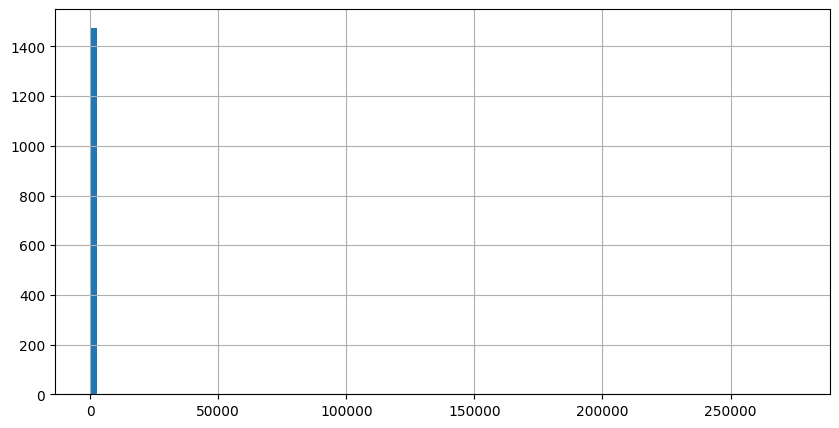

In [70]:
jobs_model["avg_salary"].hist(bins=100,figsize=(10,5))

#### **2.1.3 Detect Extreme Salary Values**

In [71]:
jobs_model.nlargest(20,"avg_salary")[
    [
        "job_title",
        "salary",
        "min_salary",
        "max_salary",
        "avg_salary",
        "source"
    ]
]

,job_title,salary,min_salary,max_salary,avg_salary,source
1848,Nhân Viên Idea Creator (Mảng POD - AI),"10,000,000 - 12,000,000 USD",250000.00,300000.00,275000.00,topcv
1602,Chuyên Viên SRE,"Tới 1,500,000 USD",0.00,37500.00,37500.00,topcv
3139,Solution Architect - Salary Up to $5000,Up to $5000,0.00,125.00,125.00,itviec
2082,Technical Manager (SaaS),"Tới 4,000 USD",0.00,100.00,100.00,topcv
3175,VIETTEL SOLUTIONS - Solutions Architect,"2,500 - 5,000 USD",62.50,125.00,93.75,itviec
2716,(HN) Expert/Manager Software Engineering,"3,000 - 4,000 USD",75.00,100.00,87.50,itviec
3155,Technical Lead (Golang) ~ Upto 3500$,Upto 3500$,0.00,87.50,87.50,itviec
3174,VIETTEL SOLUTIONS - Project Manager,"2,000 - 4,998 USD",50.00,124.95,87.47,itviec
2723,[HYBRID] Senior Java Developer,"3,200 - 3,500 USD",80.00,87.50,83.75,itviec
3092,Senior Python Developer,"3,200 - 3,500 USD",80.00,87.50,83.75,itviec


In [72]:
jobs_model[jobs_model["avg_salary"] > 500][
    [
        "job_title",
        "salary",
        "avg_salary",
        "source"
    ]
]

,job_title,salary,avg_salary,source
1602,Chuyên Viên SRE,"Tới 1,500,000 USD",37500.0,topcv
1848,Nhân Viên Idea Creator (Mảng POD - AI),"10,000,000 - 12,000,000 USD",275000.0,topcv


#### **2.1.4 Remove Salary Outliers**

In [73]:
bad_salary_mask = jobs_model["avg_salary"] > 500
jobs_model = jobs_model.loc[~bad_salary_mask].copy()
n_removed = bad_salary_mask.sum()
print(f"Removed {n_removed} salary outliers")

Removed 2 salary outliers


In [74]:
jobs_model["avg_salary"].describe(
    percentiles=[
        .90,
        .95,
        .97,
        .99,
        .995
    ]
)

count    1476.000000
mean       25.448306
std        15.772460
min         0.000000
50%        22.500000
90%        47.500000
95%        56.250000
97%        62.500000
99%        75.000000
99.5%      82.812500
max       125.000000
Name: avg_salary, dtype: float64

<Axes: >

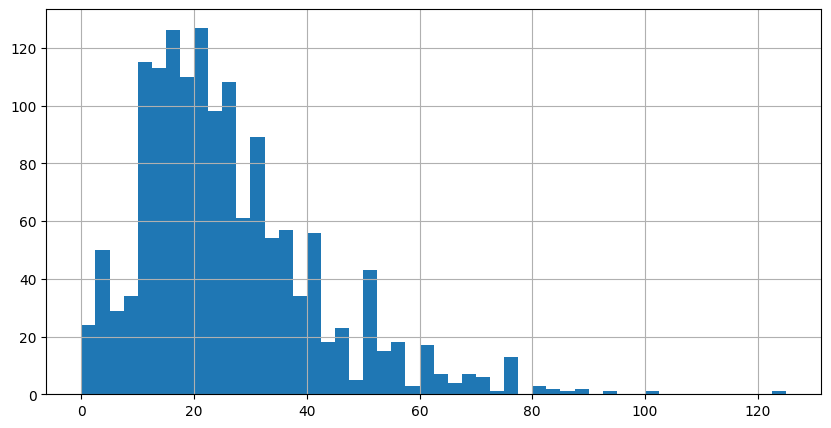

In [75]:
jobs_model["avg_salary"].hist(bins=50,figsize=(10,5))

**Kết luận**

Các tin tuyển dụng có lương thỏa thuận được loại bỏ do không có giá trị mục tiêu dạng số.

Các bản ghi có mức lương trên 500 triệu VNĐ/tháng được xem là outlier và bị loại khỏi tập modeling.

### **2.2 Log Transformation**

Phân phối lương vẫn lệch phải (right-skewed), điều này có thể ảnh hưởng đến các mô hình hồi quy tuyến tính.

Để giảm độ lệch và ổn định phương sai, nhóm áp dụng phép biến đổi:

> log_salary=log(1+avg_salary)

**Tạo biến mục tiêu**

In [76]:
jobs_model["log_salary"] = np.log1p(jobs_model["avg_salary"])
TARGET = "log_salary"

**Kiểm tra phân phối sau biến đổi**

In [77]:
jobs_model["log_salary"].describe()

count    1476.000000
mean        3.088477
std         0.658041
min         0.000000
25%         2.772589
50%         3.157000
75%         3.511545
max         4.836282
Name: log_salary, dtype: float64

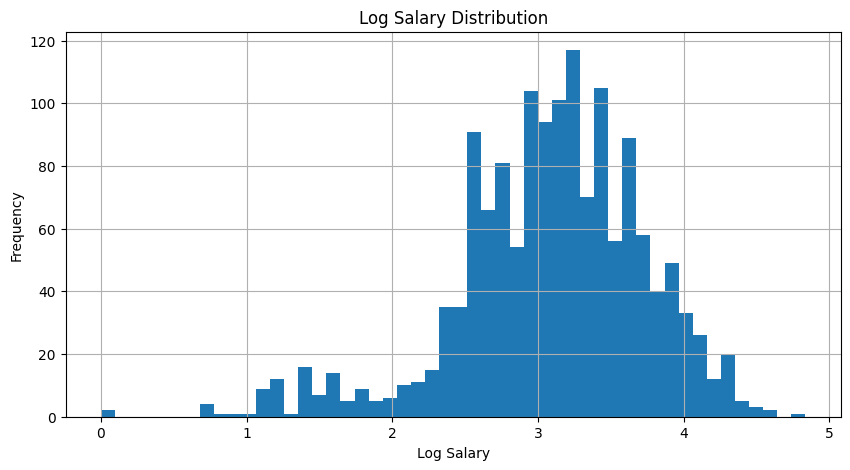

In [78]:
jobs_model["log_salary"].hist(bins=50,figsize=(10,5))
plt.title("Log Salary Distribution")
plt.xlabel("Log Salary")
plt.ylabel("Frequency")
plt.show()

In [79]:
print("Skewness before:",jobs_model["avg_salary"].skew())
print("Skewness after:",jobs_model["log_salary"].skew())

Skewness before: 1.332011920563557
Skewness after: -0.8372211851422461


**Kết luận:**

Sau khi loại bỏ các outlier rõ ràng, phân phối lương còn lại được đánh giá là hợp lý và không cần áp dụng winsorization.

Nhóm giữ nguyên các mức lương cao để bảo toàn thông tin thị trường lao động.

Cuối cùng, biến mục tiêu được chuyển sang thang logarit nhằm giảm độ lệch của phân phối và hỗ trợ quá trình huấn luyện mô hình.

## **SECTION 3 - Experiment Setup**

Mục tiêu của thí nghiệm là so sánh hai cách mã hóa:

1. One-Hot Encoding
2. Ordinal Encoding

trên cùng một tập metadata và cùng một quy trình huấn luyện **Ridge Regression**.

## **SECTION 4 - Job Metadata Features**

### **4.1 Cardinality Analysis**

In [80]:
job_features = [
    "source",
    "location",
    "industry",
    "specialization",
    "education",
    "experience_years",
    "job_level",
    "standardized_title"
]

for col in job_features:
    print(f"{col}: {jobs_model[col].nunique()}")

source: 2
location: 18
industry: 55
specialization: 1154
education: 8
experience_years: 19
job_level: 9
standardized_title: 97


### **4.2 Experience Engineering**

Kinh nghiệm làm việc đã được chuẩn hóa thành biến số `experience_years` từ bước tiền xử lý dữ liệu.

Do đó biến này được giữ nguyên dưới dạng numerical feature.

In [81]:
jobs_model["experience_years"].describe()

count    1476.000000
mean        2.160569
std         1.511749
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         9.500000
Name: experience_years, dtype: float64

In [82]:
jobs_model["experience_years"].value_counts().sort_index()

experience_years
0.0    136
0.5    111
1.0    305
1.5      4
2.0    342
2.5      8
3.0    325
3.5     28
4.0     88
4.5      9
5.0     73
5.5     31
6.0      3
6.5      3
7.0      2
7.5      2
8.0      2
8.5      3
9.5      1
Name: count, dtype: int64

### **4.3 Ordinal Encoding Experiment**

Mục tiêu của thí nghiệm này là đánh giá liệu việc khai thác tính thứ tự của:

* `job_level`
* `education`

bằng **Ordinal Encoding** có giúp cải thiện hiệu năng dự đoán hay không.

Trong notebook gốc, hai biến này được xử lý bằng **One-Hot Encoding**.

Trong notebook thí nghiệm:

* `job_level` → ordinal numeric
* `education` → ordinal numeric

Các đặc trưng còn lại giữ nguyên.

#### **4.3.1 Encode Job Level**

In [83]:
jobs_model["job_level"].value_counts(dropna=False)

job_level
Nhân viên             899
Trưởng nhóm           321
Intern                110
Senior                 62
Quản lý / Giám sát     47
Trưởng/Phó phòng       27
Junior                  6
Giám đốc                3
Fresher                 1
Name: count, dtype: int64

In [84]:
job_level_map = {
    "Intern": 0,
    "Fresher": 1,
    "Junior": 2,
    "Nhân viên": 3,
    "Senior": 4,
    "Trưởng nhóm": 5,
    "Trưởng/Phó phòng": 6,
    "Quản lý / Giám sát": 7,
    "Giám đốc": 8
}

jobs_model["job_level_ordinal"] = (jobs_model["job_level"].map(job_level_map))

In [85]:
jobs_model[["job_level","job_level_ordinal"]].head()

,job_level,job_level_ordinal
0,Nhân viên,3
2,Trưởng nhóm,5
3,Nhân viên,3
4,Nhân viên,3
5,Nhân viên,3


#### **4.3.2 Encode Education**

In [86]:
jobs_model["education"].value_counts(dropna=False)

education
Đại Học trở lên                        842
Cao Đẳng trở lên                       365
Không yêu cầu                           91
Đại học trở lên                         76
Trung cấp trở lên                       70
Trung học phổ thông (Cấp 3) trở lên     15
Thạc sĩ trở lên                         11
Cao học trở lên                          6
Name: count, dtype: int64

In [87]:
education_map = {
    "Không yêu cầu": 0,
    "Trung học phổ thông (Cấp 3) trở lên": 1,
    "Trung cấp trở lên": 2,
    "Cao Đẳng trở lên": 3,
    "Đại Học trở lên": 4,
    "Đại học trở lên": 4,
    "Thạc sĩ trở lên": 5,
    "Cao học trở lên": 5
}

jobs_model["education_ordinal"] = (
    jobs_model["education"]
    .map(education_map)
)

In [88]:
jobs_model[
    ["education", "education_ordinal"]
].head()

,education,education_ordinal
0,Đại Học trở lên,4
2,Đại Học trở lên,4
3,Đại Học trở lên,4
4,Cao Đẳng trở lên,3
5,Cao Đẳng trở lên,3


**Check sau khi map**

In [89]:
print(jobs_model["job_level_ordinal"].isna().sum())
print(jobs_model["education_ordinal"].isna().sum())

0
0


#### **Job Metadata Feature Set**

In [90]:
NUMERIC_FEATURES = [
    "experience_years",
    "job_level_ordinal",
    "education_ordinal"
]

CATEGORICAL_FEATURES = [
    "source",
    "location",
    "industry",
    "standardized_title"
]

## **SECTION 5 - Modeling Dataset**

### **5.1 Missing Values**

In [91]:
jobs_model["industry"] = (
    jobs_model["industry"]
    .fillna("Unknown")
)

jobs_model["location"] = (
    jobs_model["location"]
    .fillna("Unknown")
)

### **5.2 Create Modeling Dataset**

In [92]:
model_ready = jobs_model.copy()

In [93]:
model_ready.shape

(1476, 30)

In [94]:
model_ready.isna().sum().sum()

np.int64(356)

## **SECTION 6 - Modeling Setup**

### **6.1 Target**

In [95]:
TARGET = "log_salary"
y = model_ready[TARGET]

### **6.2 Stratified CV**

In [96]:
model_ready["salary_bin"] = pd.qcut(
    model_ready["log_salary"],
    q=5,
    labels=False
)

In [97]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

### **6.3 Feature Sets**

**Original Encoding**

In [98]:
FEATURES_ORIGINAL = [
    "source",
    "location",
    "industry",
    "education",
    "job_level",
    "standardized_title",
    "experience_years"
]

**Ordinal Encoding**

In [99]:
FEATURES_ORDINAL = [
    "source",
    "location",
    "industry",
    "standardized_title",
    "experience_years",
    "job_level_ordinal",
    "education_ordinal"
]

### **6.4 Feature Type Definition**

**Original**

In [100]:
NUMERIC_FEATURES_ORIGINAL = [
    "experience_years"
]

CATEGORICAL_FEATURES_ORIGINAL = [
    c
    for c in FEATURES_ORIGINAL
    if c not in NUMERIC_FEATURES_ORIGINAL
]

**Ordinal**

In [101]:
NUMERIC_FEATURES_ORDINAL = [
    "experience_years",
    "job_level_ordinal",
    "education_ordinal"
]

CATEGORICAL_FEATURES_ORDINAL = [
    c
    for c in FEATURES_ORDINAL
    if c not in NUMERIC_FEATURES_ORDINAL
]

## **SECTION 07 - THIẾT LẬP CROSS-VALIDATION**

Để tránh hiện tượng rò rỉ dữ liệu (data leakage) và thu được ước lượng hiệu năng đáng tin cậy, toàn bộ các thí nghiệm trong nghiên cứu này đều sử dụng **5-Fold Stratified Cross-Validation**.

Quá trình phân tầng (stratification) được thực hiện dựa trên các nhóm lương
(`salary quantiles`), nhằm đảm bảo phân phối mức lương giữa các fold tương đối đồng đều trong quá trình huấn luyện và đánh giá mô hình.

In [102]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [103]:
for fold, (
    train_idx,
    valid_idx
) in enumerate(
    cv.split(
        model_ready,
        model_ready["salary_bin"]
    )
):
    print(
        f"Fold {fold+1}",
        len(train_idx),
        len(valid_idx)
    )

Fold 1 1180 296
Fold 2 1181 295
Fold 3 1181 295
Fold 4 1181 295
Fold 5 1181 295


**Verify Stratification**

In [104]:
for fold, (_, valid_idx) in enumerate(
    cv.split(model_ready,model_ready["salary_bin"])
):
    print(f"\nFold {fold+1}")
    print(model_ready.iloc[valid_idx]["salary_bin"].value_counts().sort_index())


Fold 1
salary_bin
0    61
1    58
2    62
3    57
4    58
Name: count, dtype: int64

Fold 2
salary_bin
0    61
1    58
2    61
3    58
4    57
Name: count, dtype: int64

Fold 3
salary_bin
0    61
1    58
2    62
3    57
4    57
Name: count, dtype: int64

Fold 4
salary_bin
0    61
1    58
2    62
3    57
4    57
Name: count, dtype: int64

Fold 5
salary_bin
0    61
1    58
2    62
3    57
4    57
Name: count, dtype: int64


## **SECTION 8 - Ordinal Encoding Experiment**

Trong notebook gốc, `education` và `job_level` được mã hóa bằng **One-Hot Encoding**.

Thí nghiệm này thay thế hai biến đó bằng **Ordinal Encoding** nhằm kiểm tra liệu việc khai thác thứ tự tự nhiên của dữ liệu có giúp cải thiện hiệu năng mô hình hay không.

### **8.1 Prepare Ordinal Dataset**

In [105]:
model_ready_ord = model_ready.copy()

**Validation**

In [106]:
print(
    model_ready_ord["education_ordinal"]
    .isna()
    .sum()
)

print(
    model_ready_ord["job_level_ordinal"]
    .isna()
    .sum()
)

0
0


In [107]:
FEATURES_A_ORIGINAL = [
    "source",
    "location",
    "industry",
    "education",
    "job_level",
    "standardized_title",
    "experience_years"
]

In [108]:
FEATURES_A_ORDINAL = [
    "source",
    "location",
    "industry",
    "standardized_title",
    "experience_years",
    "education_ordinal",
    "job_level_ordinal"
]

**Validation**

In [109]:
print(
    model_ready_ord["education_ordinal"]
    .isna()
    .sum()
)

print(
    model_ready_ord["job_level_ordinal"]
    .isna()
    .sum()
)

0
0


## **SECTION 9 - Ridge Regression Experiment**

### **9.1 Preprocessor - Original Encoding**

In [110]:
preprocessor_original = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            CATEGORICAL_FEATURES_ORIGINAL
        ),
        (
            "num",
            StandardScaler(),
            NUMERIC_FEATURES_ORIGINAL
        )
    ]
)

### **9.2 Tune Alpha - Original Encoding**

In [111]:
alpha_grid = [
    0.01,
    0.1,
    1,
    10,
    100
]

In [112]:
alpha_results_original = tune_ridge_alpha(
    alphas=alpha_grid,
    X=model_ready[FEATURES_A_ORIGINAL],
    y=y,
    cv=cv,
    stratify_labels=model_ready["salary_bin"],
    preprocessor=preprocessor_original
)

In [113]:
alpha_results_original.sort_values("mae_mean")

,alpha,mae_mean,mae_std,rmse_mean,rmse_std
3,10.00,0.272407,0.022841,0.367759,0.046842
2,1.00,0.273630,0.022783,0.373649,0.046467
1,0.10,0.278401,0.022150,0.381343,0.044711
0,0.01,0.279524,0.022048,0.383183,0.044389
4,100.00,0.295851,0.025349,0.397015,0.046947


### **9.3 Best Alpha**

In [114]:
BEST_ALPHA = (
    alpha_results_original
    .sort_values("mae_mean")
    .iloc[0]["alpha"]
)

BEST_ALPHA

np.float64(10.0)

### **9.4 Evaluate Original Encoding**

In [115]:
ridge_original = build_ridge_pipeline(
    preprocessor=preprocessor_original,
    alpha=BEST_ALPHA
)

In [116]:
ridge_original_results = evaluate_model(
    model=ridge_original,
    X=model_ready[FEATURES_A_ORIGINAL],
    y=y,
    cv=cv,
    stratify_labels=model_ready["salary_bin"]
)

In [117]:
ridge_original_summary = get_model_summary(
    ridge_original_results
)

ridge_original_summary

,mae,rmse
mean,0.272407,0.367759
std,0.022841,0.046842


## **SECTION 10 - Ordinal Encoding Model**

### **10.1 Preprocessor - Ordinal Encoding**

In [118]:
preprocessor_ordinal = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            CATEGORICAL_FEATURES_ORDINAL
        ),
        (
            "num",
            StandardScaler(),
            NUMERIC_FEATURES_ORDINAL
        )
    ]
)

### **10.2 Evaluate Ordinal Encoding**

In [119]:
ridge_ordinal = build_ridge_pipeline(
    preprocessor=preprocessor_ordinal,
    alpha=BEST_ALPHA
)

In [120]:
ridge_ordinal_results = evaluate_model(
    model=ridge_ordinal,
    X=model_ready_ord[FEATURES_A_ORDINAL],
    y=y,
    cv=cv,
    stratify_labels=model_ready_ord["salary_bin"]
)

In [121]:
ridge_ordinal_summary = get_model_summary(
    ridge_ordinal_results
)

ridge_ordinal_summary

,mae,rmse
mean,0.303532,0.407518
std,0.025415,0.047617


## **SECTION 11 - Comparison**

### **11.1 Results Table**

In [122]:
comparison_df = pd.DataFrame(
    [
        {
            "version": "One-Hot Encoding",
            "mae": ridge_original_results["mae"].mean(),
            "rmse": ridge_original_results["rmse"].mean()
        },
        {
            "version": "Ordinal Encoding",
            "mae": ridge_ordinal_results["mae"].mean(),
            "rmse": ridge_ordinal_results["rmse"].mean()
        }
    ]
)

comparison_df

,version,mae,rmse
0,One-Hot Encoding,0.272407,0.367759
1,Ordinal Encoding,0.303532,0.407518


### **11.2 Visualization**

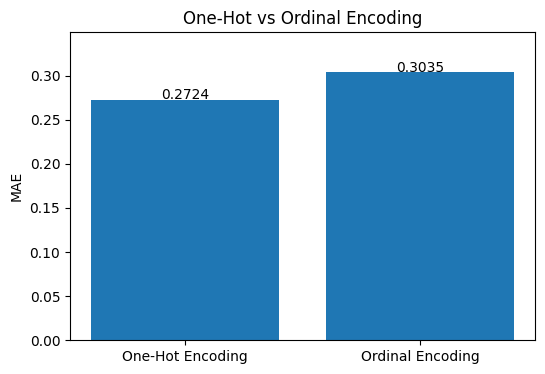

In [123]:
plt.figure(figsize=(6,4))

bars = plt.bar(
    comparison_df["version"],
    comparison_df["mae"]
)

plt.ylabel("MAE")
plt.title("One-Hot vs Ordinal Encoding")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.001,
        f"{height:.4f}",
        ha="center"
    )

plt.ylim(
    0,
    comparison_df["mae"].max() * 1.15
)

plt.show()

## **SECTION 12 - Conclusion**

Kết quả thực nghiệm cho thấy việc sử dụng **Ordinal Encoding** cho các biến `job_level` và `education` làm giảm hiệu năng dự đoán của mô hình so với **One-Hot Encoding**.

Mặc dù `job_level` và `education` có bản chất thứ tự, việc biểu diễn bằng giá trị số đã làm mô hình áp đặt quan hệ tuyến tính giữa các cấp độ, trong khi **One-Hot Encoding** cho phép mô hình học ảnh hưởng riêng của từng nhóm.

Do đó, **One-Hot Encoding** tiếp tục được sử dụng trong notebook chính và trong mô hình cuối cùng.